# Peak 1

===== Hill fit results =====
Kd_fit  = 2.336e-08 (mol/L)^n
Kd      = 1.578e-04 mol/L
n       = 2.007
R²      = 0.662


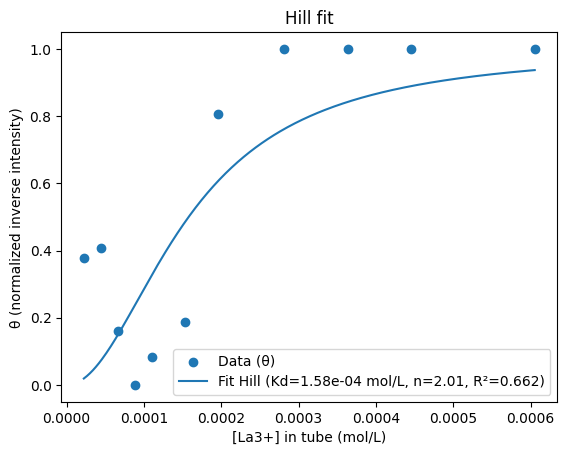

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DONNÉES
# =========================
L = np.array([
    0.0,
    2.217e-05,
    4.425e-05,
    6.623e-05,
    8.811e-05,
    1.099e-04,
    1.532e-04,
    1.961e-04,
    2.808e-04,
    3.640e-04,
    4.459e-04,
    6.054e-04
], dtype=float)

I = np.array([
    20787000000,
    16721000000,
    16354000000,
    19501000000,
    21522000000,
    20481000000,
    19151000000,
    11281000000,
    8843500000,
    8843500000,
    8843500000,
    8843500000
], dtype=float)

# =========================
# NORMALISATION
# Eq (9): theta' = (I - Imin)/(Imax - Imin)
# Eq (10): theta = |1 - theta'|
# =========================
def theta_from_integrals(I_values):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de normaliser ce pic.")

    theta_prime = (I_values - Imin) / (Imax - Imin)
    theta = np.abs(1.0 - theta_prime)
    return theta

theta = theta_from_integrals(I)

# =========================
# MODELE DE HILL
# Ici, le paramètre Kd_fit est en réalité la constante du fit :
# theta = [L]^n / ([L]^n + Kd_fit)
# Le vrai Kd en mol/L est donc : Kd_true = Kd_fit^(1/n)
# =========================
def hill_model(L_values, Kd_fit, n):
    L_values = np.asarray(L_values, dtype=float)
    return (L_values**n) / (L_values**n + Kd_fit)

# =========================
# PREPARATION DU FIT
# =========================
mask = np.isfinite(L) & np.isfinite(theta) & (L > 0)
L_fit = L[mask]
theta_fit = theta[mask]

# point de départ intelligent
idx = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0_true = float(L_fit[idx])     # estimation initiale du vrai Kd
n0 = 2.0
Kd0_fit = Kd0_true**n0           # conversion vers le paramètre du modèle

bounds = ([1e-20, 0.1], [1e0, 20.0])

params, cov = curve_fit(
    hill_model,
    L_fit,
    theta_fit,
    p0=[Kd0_fit, n0],
    bounds=bounds,
    maxfev=20000
)

Kd_fit, n_fit = params
Kd_true = Kd_fit**(1.0 / n_fit)

# =========================
# CALCUL DE R²
# =========================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)
ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# AFFICHAGE RESULTATS
# =========================
print("===== Hill fit results =====")
print(f"Kd_fit  = {Kd_fit:.3e} (mol/L)^n")
print(f"Kd      = {Kd_true:.3e} mol/L")
print(f"n       = {n_fit:.3f}")
print(f"R²      = {R2:.3f}")

# =========================
# COURBE AJUSTEE
# =========================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 300)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure()
plt.scatter(L_fit, theta_fit, label="Data (θ)")
plt.plot(
    L_curve,
    theta_curve,
    label=f"Fit Hill (Kd={Kd_true:.2e} mol/L, n={n_fit:.2f}, R²={R2:.3f})"
)
plt.xlabel("[La3+] in tube (mol/L)")
plt.ylabel("θ (normalized inverse intensity)")
plt.title("Hill fit")
plt.legend()
plt.show()

# Peak 2

===== Hill fit results =====
Kd_fit  = 2.049e-08 (mol/L)^n
Kd      = 1.789e-04 mol/L
n       = 2.052
R²      = 0.894


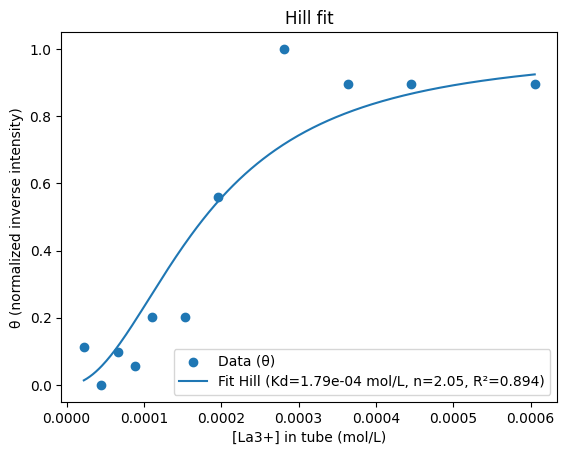

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DONNÉES
# =========================
L = np.array([
      0.0,
    2.217e-05,
    4.425e-05,
    6.623e-05,
    8.811e-05,
    1.099e-04,
    1.532e-04,
    1.961e-04,
    2.808e-04,
    3.640e-04,
    4.459e-04,
    6.054e-04

], dtype=float)

I = np.array([
    32454000000.00,
    32324000000.00,
    34610000000.00,
    32659000000.00,
    33457000000.00,
    30566000000.00,
    30561000000.00,
    23361000000.00,
    14495000000.00,
    16597000000.00,
    16597000000.00,
    16597000000.00
], dtype=float)

# =========================
# NORMALISATION
# Eq (9): theta' = (I - Imin)/(Imax - Imin)
# Eq (10): theta = |1 - theta'|
# =========================
def theta_from_integrals(I_values):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de normaliser ce pic.")

    theta_prime = (I_values - Imin) / (Imax - Imin)
    theta = np.abs(1.0 - theta_prime)
    return theta

theta = theta_from_integrals(I)

# =========================
# MODELE DE HILL
# Ici, le paramètre Kd_fit est en réalité la constante du fit :
# theta = [L]^n / ([L]^n + Kd_fit)
# Le vrai Kd en mol/L est donc : Kd_true = Kd_fit^(1/n)
# =========================
def hill_model(L_values, Kd_fit, n):
    L_values = np.asarray(L_values, dtype=float)
    return (L_values**n) / (L_values**n + Kd_fit)

# =========================
# PREPARATION DU FIT
# =========================
mask = np.isfinite(L) & np.isfinite(theta) & (L > 0)
L_fit = L[mask]
theta_fit = theta[mask]

# point de départ intelligent
idx = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0_true = float(L_fit[idx])     # estimation initiale du vrai Kd
n0 = 2.0
Kd0_fit = Kd0_true**n0           # conversion vers le paramètre du modèle

bounds = ([1e-20, 0.1], [1e0, 20.0])

params, cov = curve_fit(
    hill_model,
    L_fit,
    theta_fit,
    p0=[Kd0_fit, n0],
    bounds=bounds,
    maxfev=20000
)

Kd_fit, n_fit = params
Kd_true = Kd_fit**(1.0 / n_fit)

# =========================
# CALCUL DE R²
# =========================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)
ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# AFFICHAGE RESULTATS
# =========================
print("===== Hill fit results =====")
print(f"Kd_fit  = {Kd_fit:.3e} (mol/L)^n")
print(f"Kd      = {Kd_true:.3e} mol/L")
print(f"n       = {n_fit:.3f}")
print(f"R²      = {R2:.3f}")

# =========================
# COURBE AJUSTEE
# =========================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 300)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure()
plt.scatter(L_fit, theta_fit, label="Data (θ)")
plt.plot(
    L_curve,
    theta_curve,
    label=f"Fit Hill (Kd={Kd_true:.2e} mol/L, n={n_fit:.2f}, R²={R2:.3f})"
)
plt.xlabel("[La3+] in tube (mol/L)")
plt.ylabel("θ (normalized inverse intensity)")
plt.title("Hill fit")
plt.legend()
plt.show()

# Peak 3

===== Hill fit results =====
Kd_fit  = 2.143e-08 (mol/L)^n
Kd      = 1.410e-04 mol/L
n       = 1.991
R²      = 0.863


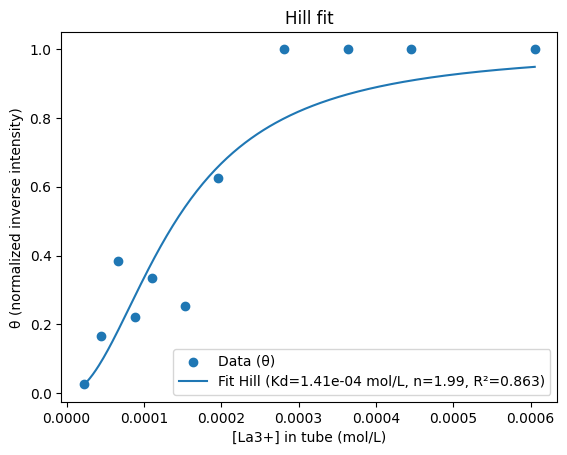

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DONNÉES
# =========================
L = np.array([
    0.0,
    2.217e-05,
    4.425e-05,
    6.623e-05,
    8.811e-05,
    1.099e-04,
    1.532e-04,
    1.961e-04,
    2.808e-04,
    3.640e-04,
    4.459e-04,
    6.054e-04

], dtype=float)

I = np.array([
    21326000000.00,
    20926000000.00,
    18881000000.00,
    15643000000.00,
    18056000000.00,
    16376000000.00,
    17585000000.00,
    12097000000.00,
    6588100000.00,
    6588100000.00,
    6588100000.00,
    6588100000.00
], dtype=float)

# =========================
# NORMALISATION
# Eq (9): theta' = (I - Imin)/(Imax - Imin)
# Eq (10): theta = |1 - theta'|
# =========================
def theta_from_integrals(I_values):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de normaliser ce pic.")

    theta_prime = (I_values - Imin) / (Imax - Imin)
    theta = np.abs(1.0 - theta_prime)
    return theta

theta = theta_from_integrals(I)

# =========================
# MODELE DE HILL
# Ici, le paramètre Kd_fit est en réalité la constante du fit :
# theta = [L]^n / ([L]^n + Kd_fit)
# Le vrai Kd en mol/L est donc : Kd_true = Kd_fit^(1/n)
# =========================
def hill_model(L_values, Kd_fit, n):
    L_values = np.asarray(L_values, dtype=float)
    return (L_values**n) / (L_values**n + Kd_fit)

# =========================
# PREPARATION DU FIT
# =========================
mask = np.isfinite(L) & np.isfinite(theta) & (L > 0)
L_fit = L[mask]
theta_fit = theta[mask]

# point de départ intelligent
idx = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0_true = float(L_fit[idx])     # estimation initiale du vrai Kd
n0 = 2.0
Kd0_fit = Kd0_true**n0           # conversion vers le paramètre du modèle

bounds = ([1e-20, 0.1], [1e0, 20.0])

params, cov = curve_fit(
    hill_model,
    L_fit,
    theta_fit,
    p0=[Kd0_fit, n0],
    bounds=bounds,
    maxfev=20000
)

Kd_fit, n_fit = params
Kd_true = Kd_fit**(1.0 / n_fit)

# =========================
# CALCUL DE R²
# =========================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)
ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# AFFICHAGE RESULTATS
# =========================
print("===== Hill fit results =====")
print(f"Kd_fit  = {Kd_fit:.3e} (mol/L)^n")
print(f"Kd      = {Kd_true:.3e} mol/L")
print(f"n       = {n_fit:.3f}")
print(f"R²      = {R2:.3f}")

# =========================
# COURBE AJUSTEE
# =========================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 300)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure()
plt.scatter(L_fit, theta_fit, label="Data (θ)")
plt.plot(
    L_curve,
    theta_curve,
    label=f"Fit Hill (Kd={Kd_true:.2e} mol/L, n={n_fit:.2f}, R²={R2:.3f})"
)
plt.xlabel("[La3+] in tube (mol/L)")
plt.ylabel("θ (normalized inverse intensity)")
plt.title("Hill fit")
plt.legend()
plt.show()

# Peak 4

===== Hill fit results =====
Kd_fit  = 2.966e-08 (mol/L)^n
Kd      = 1.508e-04 mol/L
n       = 1.970
R²      = 0.550


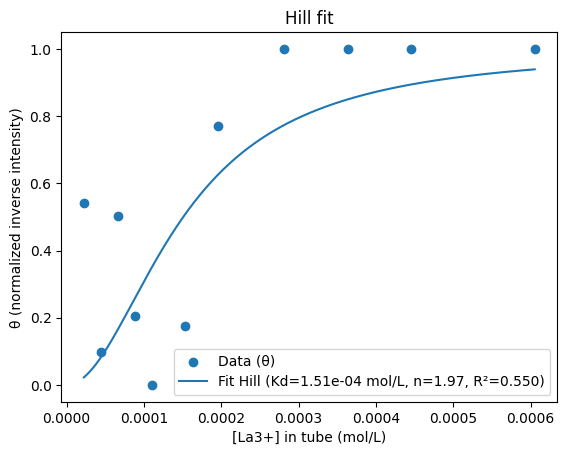

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DONNÉES
# =========================
L = np.array([
    0.0,
    2.217e-05,
    4.425e-05,
    6.623e-05,
    8.811e-05,
    1.099e-04,
    1.532e-04,
    1.961e-04,
    2.808e-04,
    3.640e-04,
    4.459e-04,
    6.054e-04

], dtype=float)

I = np.array([
    20191000000.00,
    17238000000.00,
    22165000000.00,
    17663000000.00,
    20958000000.00,
    23243000000.00,
    21290000000.00,
    14716000000.00,
    12164000000.00,
    12164000000.00,
    12164000000.00,
    12164000000.00
], dtype=float)

# =========================
# NORMALISATION
# Eq (9): theta' = (I - Imin)/(Imax - Imin)
# Eq (10): theta = |1 - theta'|
# =========================
def theta_from_integrals(I_values):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de normaliser ce pic.")

    theta_prime = (I_values - Imin) / (Imax - Imin)
    theta = np.abs(1.0 - theta_prime)
    return theta

theta = theta_from_integrals(I)

# =========================
# MODELE DE HILL
# Ici, le paramètre Kd_fit est en réalité la constante du fit :
# theta = [L]^n / ([L]^n + Kd_fit)
# Le vrai Kd en mol/L est donc : Kd_true = Kd_fit^(1/n)
# =========================
def hill_model(L_values, Kd_fit, n):
    L_values = np.asarray(L_values, dtype=float)
    return (L_values**n) / (L_values**n + Kd_fit)

# =========================
# PREPARATION DU FIT
# =========================
mask = np.isfinite(L) & np.isfinite(theta) & (L > 0)
L_fit = L[mask]
theta_fit = theta[mask]

# point de départ intelligent
idx = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0_true = float(L_fit[idx])     # estimation initiale du vrai Kd
n0 = 2.0
Kd0_fit = Kd0_true**n0           # conversion vers le paramètre du modèle

bounds = ([1e-20, 0.1], [1e0, 20.0])

params, cov = curve_fit(
    hill_model,
    L_fit,
    theta_fit,
    p0=[Kd0_fit, n0],
    bounds=bounds,
    maxfev=20000
)

Kd_fit, n_fit = params
Kd_true = Kd_fit**(1.0 / n_fit)

# =========================
# CALCUL DE R²
# =========================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)
ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# AFFICHAGE RESULTATS
# =========================
print("===== Hill fit results =====")
print(f"Kd_fit  = {Kd_fit:.3e} (mol/L)^n")
print(f"Kd      = {Kd_true:.3e} mol/L")
print(f"n       = {n_fit:.3f}")
print(f"R²      = {R2:.3f}")

# =========================
# COURBE AJUSTEE
# =========================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 300)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure()
plt.scatter(L_fit, theta_fit, label="Data (θ)")
plt.plot(
    L_curve,
    theta_curve,
    label=f"Fit Hill (Kd={Kd_true:.2e} mol/L, n={n_fit:.2f}, R²={R2:.3f})"
)
plt.xlabel("[La3+] in tube (mol/L)")
plt.ylabel("θ (normalized inverse intensity)")
plt.title("Hill fit")
plt.legend()
plt.show()

# Peak 5

===== Hill fit results =====
Kd_fit  = 2.191e-01 (mol/L)^n
Kd      = 3.040e-05 mol/L
n       = 0.146
R²      = 0.017


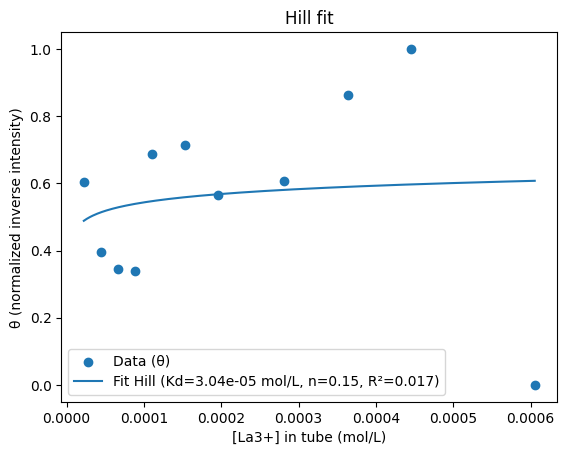

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DONNÉES
# =========================
L = np.array([
    0.0,
    2.217e-05,
    4.425e-05,
    6.623e-05,
    8.811e-05,
    1.099e-04,
    1.532e-04,
    1.961e-04,
    2.808e-04,
    3.640e-04,
    4.459e-04,
    6.054e-04

], dtype=float)

I = np.array([
    28329000000.00,
    29729000000.00,
    33986000000.00,
    35022000000.00,
    35170000000.00,
    28058000000.00,
    27534000000.00,
    30556000000.00,
    29710000000.00,
    24494000000.00,
    21683000000.00,
    42045000000.00
], dtype=float)

# =========================
# NORMALISATION
# Eq (9): theta' = (I - Imin)/(Imax - Imin)
# Eq (10): theta = |1 - theta'|
# =========================
def theta_from_integrals(I_values):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de normaliser ce pic.")

    theta_prime = (I_values - Imin) / (Imax - Imin)
    theta = np.abs(1.0 - theta_prime)
    return theta

theta = theta_from_integrals(I)

# =========================
# MODELE DE HILL
# Ici, le paramètre Kd_fit est en réalité la constante du fit :
# theta = [L]^n / ([L]^n + Kd_fit)
# Le vrai Kd en mol/L est donc : Kd_true = Kd_fit^(1/n)
# =========================
def hill_model(L_values, Kd_fit, n):
    L_values = np.asarray(L_values, dtype=float)
    return (L_values**n) / (L_values**n + Kd_fit)

# =========================
# PREPARATION DU FIT
# =========================
mask = np.isfinite(L) & np.isfinite(theta) & (L > 0)
L_fit = L[mask]
theta_fit = theta[mask]

# point de départ intelligent
idx = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0_true = float(L_fit[idx])     # estimation initiale du vrai Kd
n0 = 2.0
Kd0_fit = Kd0_true**n0           # conversion vers le paramètre du modèle

bounds = ([1e-20, 0.1], [1e0, 20.0])

params, cov = curve_fit(
    hill_model,
    L_fit,
    theta_fit,
    p0=[Kd0_fit, n0],
    bounds=bounds,
    maxfev=20000
)

Kd_fit, n_fit = params
Kd_true = Kd_fit**(1.0 / n_fit)

# =========================
# CALCUL DE R²
# =========================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)
ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# AFFICHAGE RESULTATS
# =========================
print("===== Hill fit results =====")
print(f"Kd_fit  = {Kd_fit:.3e} (mol/L)^n")
print(f"Kd      = {Kd_true:.3e} mol/L")
print(f"n       = {n_fit:.3f}")
print(f"R²      = {R2:.3f}")

# =========================
# COURBE AJUSTEE
# =========================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 300)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure()
plt.scatter(L_fit, theta_fit, label="Data (θ)")
plt.plot(
    L_curve,
    theta_curve,
    label=f"Fit Hill (Kd={Kd_true:.2e} mol/L, n={n_fit:.2f}, R²={R2:.3f})"
)
plt.xlabel("[La3+] in tube (mol/L)")
plt.ylabel("θ (normalized inverse intensity)")
plt.title("Hill fit")
plt.legend()
plt.show()

# Peak 6

===== Hill fit results =====


Kd_fit  = 2.039e-08 (mol/L)^n
Kd      = 1.661e-04 mol/L
n       = 2.035
R²      = 0.822


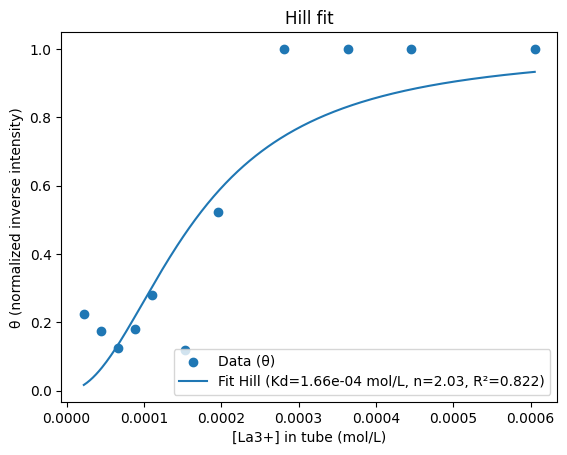

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DONNÉES
# =========================
L = np.array([
    0.0,
    2.217e-05,
    4.425e-05,
    6.623e-05,
    8.811e-05,
    1.099e-04,
    1.532e-04,
    1.961e-04,
    2.808e-04,
    3.640e-04,
    4.459e-04,
    6.054e-04

], dtype=float)

I = np.array([
     36461000000.00,
    32129000000.00,
    33072000000.00,
    34072000000.00,
    32963000000.00,
    31044000000.00,
    34141000000.00,
    26313000000.00,
    17045000000.00,
    17045000000.00,
    17045000000.00,
    17045000000.00
], dtype=float)

# =========================
# NORMALISATION
# Eq (9): theta' = (I - Imin)/(Imax - Imin)
# Eq (10): theta = |1 - theta'|
# =========================
def theta_from_integrals(I_values):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de normaliser ce pic.")

    theta_prime = (I_values - Imin) / (Imax - Imin)
    theta = np.abs(1.0 - theta_prime)
    return theta

theta = theta_from_integrals(I)

# =========================
# MODELE DE HILL
# Ici, le paramètre Kd_fit est en réalité la constante du fit :
# theta = [L]^n / ([L]^n + Kd_fit)
# Le vrai Kd en mol/L est donc : Kd_true = Kd_fit^(1/n)
# =========================
def hill_model(L_values, Kd_fit, n):
    L_values = np.asarray(L_values, dtype=float)
    return (L_values**n) / (L_values**n + Kd_fit)

# =========================
# PREPARATION DU FIT
# =========================
mask = np.isfinite(L) & np.isfinite(theta) & (L > 0)
L_fit = L[mask]
theta_fit = theta[mask]

# point de départ intelligent
idx = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0_true = float(L_fit[idx])     # estimation initiale du vrai Kd
n0 = 2.0
Kd0_fit = Kd0_true**n0           # conversion vers le paramètre du modèle

bounds = ([1e-20, 0.1], [1e0, 20.0])

params, cov = curve_fit(
    hill_model,
    L_fit,
    theta_fit,
    p0=[Kd0_fit, n0],
    bounds=bounds,
    maxfev=20000
)

Kd_fit, n_fit = params
Kd_true = Kd_fit**(1.0 / n_fit)

# =========================
# CALCUL DE R²
# =========================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)
ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# AFFICHAGE RESULTATS
# =========================
print("===== Hill fit results =====")
print(f"Kd_fit  = {Kd_fit:.3e} (mol/L)^n")
print(f"Kd      = {Kd_true:.3e} mol/L")
print(f"n       = {n_fit:.3f}")
print(f"R²      = {R2:.3f}")

# =========================
# COURBE AJUSTEE
# =========================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 300)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure()
plt.scatter(L_fit, theta_fit, label="Data (θ)")
plt.plot(
    L_curve,
    theta_curve,
    label=f"Fit Hill (Kd={Kd_true:.2e} mol/L, n={n_fit:.2f}, R²={R2:.3f})"
)
plt.xlabel("[La3+] in tube (mol/L)")
plt.ylabel("θ (normalized inverse intensity)")
plt.title("Hill fit")
plt.legend()
plt.show()

# Peak 7

===== Hill fit results =====
Kd_fit  = 5.033e-09 (mol/L)^n
Kd      = 1.449e-04 mol/L
n       = 2.162
R²      = 0.823


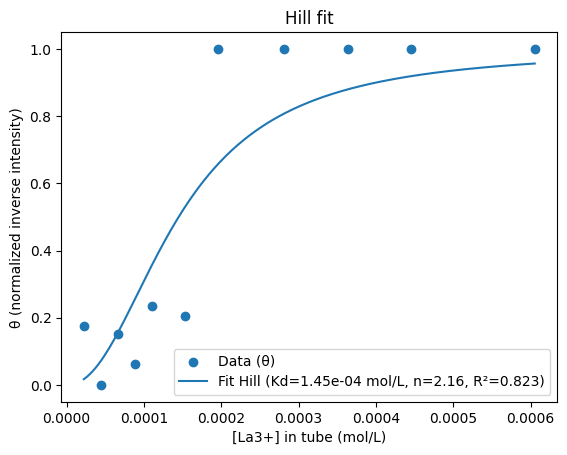

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DONNÉES
# =========================
L = np.array([
    0.0,
    2.217e-05,
    4.425e-05,
    6.623e-05,
    8.811e-05,
    1.099e-04,
    1.532e-04,
    1.961e-04,
    2.808e-04,
    3.640e-04,
    4.459e-04,
    6.054e-04

], dtype=float)

I = np.array([
    45689000000.00,
    45955000000.00,
    50415000000.00,
    46539000000.00,
    48834000000.00,
    44446000000.00,
    45251000000.00,
    25073000000.00,
    25073000000.00,
    25073000000.00,
    25073000000.00,
    25073000000.00
], dtype=float)

# =========================
# NORMALISATION
# Eq (9): theta' = (I - Imin)/(Imax - Imin)
# Eq (10): theta = |1 - theta'|
# =========================
def theta_from_integrals(I_values):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de normaliser ce pic.")

    theta_prime = (I_values - Imin) / (Imax - Imin)
    theta = np.abs(1.0 - theta_prime)
    return theta

theta = theta_from_integrals(I)

# =========================
# MODELE DE HILL
# Ici, le paramètre Kd_fit est en réalité la constante du fit :
# theta = [L]^n / ([L]^n + Kd_fit)
# Le vrai Kd en mol/L est donc : Kd_true = Kd_fit^(1/n)
# =========================
def hill_model(L_values, Kd_fit, n):
    L_values = np.asarray(L_values, dtype=float)
    return (L_values**n) / (L_values**n + Kd_fit)

# =========================
# PREPARATION DU FIT
# =========================
mask = np.isfinite(L) & np.isfinite(theta) & (L > 0)
L_fit = L[mask]
theta_fit = theta[mask]

# point de départ intelligent
idx = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0_true = float(L_fit[idx])     # estimation initiale du vrai Kd
n0 = 2.0
Kd0_fit = Kd0_true**n0           # conversion vers le paramètre du modèle

bounds = ([1e-20, 0.1], [1e0, 20.0])

params, cov = curve_fit(
    hill_model,
    L_fit,
    theta_fit,
    p0=[Kd0_fit, n0],
    bounds=bounds,
    maxfev=20000
)

Kd_fit, n_fit = params
Kd_true = Kd_fit**(1.0 / n_fit)

# =========================
# CALCUL DE R²
# =========================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)
ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# AFFICHAGE RESULTATS
# =========================
print("===== Hill fit results =====")
print(f"Kd_fit  = {Kd_fit:.3e} (mol/L)^n")
print(f"Kd      = {Kd_true:.3e} mol/L")
print(f"n       = {n_fit:.3f}")
print(f"R²      = {R2:.3f}")

# =========================
# COURBE AJUSTEE
# =========================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 300)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure()
plt.scatter(L_fit, theta_fit, label="Data (θ)")
plt.plot(
    L_curve,
    theta_curve,
    label=f"Fit Hill (Kd={Kd_true:.2e} mol/L, n={n_fit:.2f}, R²={R2:.3f})"
)
plt.xlabel("[La3+] in tube (mol/L)")
plt.ylabel("θ (normalized inverse intensity)")
plt.title("Hill fit")
plt.legend()
plt.show()

# Peak 8

===== Hill fit results =====
Kd_fit  = 1.250e-07 (mol/L)^n
Kd      = 1.043e-04 mol/L
n       = 1.734
R²      = 0.809


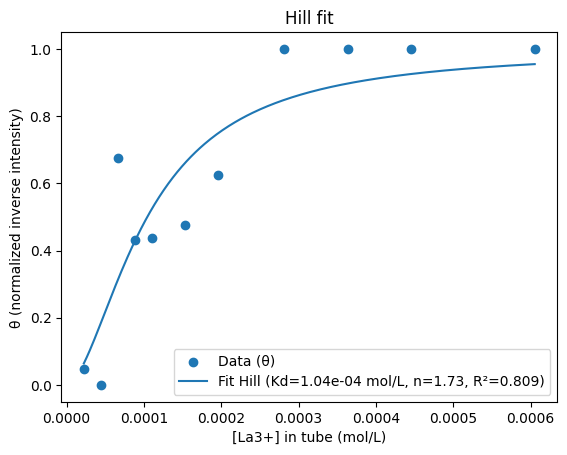

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DONNÉES
# =========================
L = np.array([
    0.0,
    2.217e-05,
    4.425e-05,
    6.623e-05,
    8.811e-05,
    1.099e-04,
    1.532e-04,
    1.961e-04,
    2.808e-04,
    3.640e-04,
    4.459e-04,
    6.054e-04

], dtype=float)

I = np.array([
    19462000000.00,
    22211000000.00,
    22715000000.00,
    15563000000.00,
    18151000000.00,
    18081000000.00,
    17665000000.00,
    16104000000.00,
    12131000000.00,
    12131000000.00,
    12131000000.00,
    12131000000.00
], dtype=float)

# =========================
# NORMALISATION
# Eq (9): theta' = (I - Imin)/(Imax - Imin)
# Eq (10): theta = |1 - theta'|
# =========================
def theta_from_integrals(I_values):
    I_values = np.asarray(I_values, dtype=float)
    Imin = np.min(I_values)
    Imax = np.max(I_values)

    if np.isclose(Imax, Imin):
        raise ValueError("Imax == Imin : impossible de normaliser ce pic.")

    theta_prime = (I_values - Imin) / (Imax - Imin)
    theta = np.abs(1.0 - theta_prime)
    return theta

theta = theta_from_integrals(I)

# =========================
# MODELE DE HILL
# Ici, le paramètre Kd_fit est en réalité la constante du fit :
# theta = [L]^n / ([L]^n + Kd_fit)
# Le vrai Kd en mol/L est donc : Kd_true = Kd_fit^(1/n)
# =========================
def hill_model(L_values, Kd_fit, n):
    L_values = np.asarray(L_values, dtype=float)
    return (L_values**n) / (L_values**n + Kd_fit)

# =========================
# PREPARATION DU FIT
# =========================
mask = np.isfinite(L) & np.isfinite(theta) & (L > 0)
L_fit = L[mask]
theta_fit = theta[mask]

# point de départ intelligent
idx = int(np.argmin(np.abs(theta_fit - 0.5)))
Kd0_true = float(L_fit[idx])     # estimation initiale du vrai Kd
n0 = 2.0
Kd0_fit = Kd0_true**n0           # conversion vers le paramètre du modèle

bounds = ([1e-20, 0.1], [1e0, 20.0])

params, cov = curve_fit(
    hill_model,
    L_fit,
    theta_fit,
    p0=[Kd0_fit, n0],
    bounds=bounds,
    maxfev=20000
)

Kd_fit, n_fit = params
Kd_true = Kd_fit**(1.0 / n_fit)

# =========================
# CALCUL DE R²
# =========================
theta_pred = hill_model(L_fit, Kd_fit, n_fit)
ss_res = np.sum((theta_fit - theta_pred) ** 2)
ss_tot = np.sum((theta_fit - np.mean(theta_fit)) ** 2)
R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# =========================
# AFFICHAGE RESULTATS
# =========================
print("===== Hill fit results =====")
print(f"Kd_fit  = {Kd_fit:.3e} (mol/L)^n")
print(f"Kd      = {Kd_true:.3e} mol/L")
print(f"n       = {n_fit:.3f}")
print(f"R²      = {R2:.3f}")

# =========================
# COURBE AJUSTEE
# =========================
L_curve = np.linspace(L_fit.min(), L_fit.max(), 300)
theta_curve = hill_model(L_curve, Kd_fit, n_fit)

plt.figure()
plt.scatter(L_fit, theta_fit, label="Data (θ)")
plt.plot(
    L_curve,
    theta_curve,
    label=f"Fit Hill (Kd={Kd_true:.2e} mol/L, n={n_fit:.2f}, R²={R2:.3f})"
)
plt.xlabel("[La3+] in tube (mol/L)")
plt.ylabel("θ (normalized inverse intensity)")
plt.title("Hill fit")
plt.legend()
plt.show()